# Practice Activity: Text Data - Spam Emails

In this activity you'll work with a small sample from the [Enron email corpus](https://en.wikipedia.org/wiki/Enron_Corpus). The [data set we'll use](https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/enron_email.csv) contains the subjects and bodies of a sample of e-mails that the Federal Energy Regulatory Commission (FERC) collected during their 2002 investigation of the energy company [Enron](https://en.wikipedia.org/wiki/Enron). Each row in the data set is an email and there are three columns

- subject: the subject of the email
- body: the text of the email
- spam: spam indicator, 1 if spam, 0 if not

For this activity we will only consider the body of the emails (though you could also include the subject using similar methods).

1\. The corpus is the body column in the [data set](https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/enron_email.csv); read this column in to create the corpus.


In [2]:
import pandas as pd

corpus = pd.read_csv("https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/enron_email.csv")["body"]

2\. Describe in words in detail the steps that you would take to clean the emails and create the term-frequency matrix. We will write the code in the next part, but think carefully first about the process: how do we turn this text into tabular data?


**First normalize the text. Then tokenize the text so we can count each unit/word. Then build a table with each column corresponding to a unique token from the corpus. Finally, count how many times each word appears, noting the frequency in the column corresponding to that token.**

3\. Use `CountVectorizer` to create the TF matrix, and then convert it to a pandas data frame with appropriate column names. You can just use the defaults in `CountVectorizer`. Hint: this should pretty much be a straight copy of code from the reading, but make sure you understand the process behind the code.


In [3]:
from sklearn.feature_extraction.text import CountVectorizer

corpus = corpus.fillna("")
tokens = corpus.str.lower().str.findall(r"\w+")
tokens = tokens.astype(str)
tokens.apply(len)


0        348
1       3394
2        344
3       1642
4       1647
        ... 
1985    1354
1986     143
1987     868
1988    4102
1989     586
Name: body, Length: 1990, dtype: int64

In [4]:
vec = CountVectorizer()
vec.fit(corpus)
vocab = vec.get_feature_names_out()
vocab, len(vocab)

(array(['00', '000', '0000', ..., 'zzezrjok', 'zzo', 'zzso'],
       shape=(34942,), dtype=object),
 34942)

In [5]:
tf = vec.transform(corpus)
tf.shape

(1990, 34942)

In [6]:
tf_df = pd.DataFrame(tf.toarray(), columns=vocab)
tf_df2 = pd.DataFrame(vec.fit_transform(corpus).toarray(), columns=vec.get_feature_names_out())
tf_df2.head()

,00,000,0000,000000,000000000002858,000000000049773,000080,0001,00020608,0004,...,zyban,zykfe,zyl,zynsdirnh,zynve,zyqtaqlt,zyyqywp,zzezrjok,zzo,zzso
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


4\. Explain what a document frequency (DF) is, and the idea of an IDF. Why might we use TF-IDF rather than just TF? This question is asking about concepts rather than computations.

DF is the number of documents that contain a word. An IDF allows us to measure the rarity or distinctiveness of a word. We might use TF-IDF rather than just TF because TF only measures how often a word occurs within a document, so TF-IDF balances this by considering both how frequent the word is in a document, and how rare it is across other documents. 

5\. Use `TfidfVectorizer` to create the TF matrix, and then convert it to a pandas data frame with appropriate column names. You can just use the defaults in `TfidfVectorizer`. Hint: this should pretty much be a straight copy of code from the reading, but make sure you understand the process behind the code.

In [7]:
# ENTER YOUR CODE HERE. FEEL FREE TO ADD CELLS
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vec = TfidfVectorizer()
tfidf_df = pd.DataFrame(tfidf_vec.fit_transform(corpus).toarray(),
                        columns=tfidf_vec.get_feature_names_out())


6\. Remember that the data set also contains an indicator of whether or not the email is spam. In this part you will use descriptive statistics and plots to compare the spam and non-spam emails in terms of their text, represented by the TF and TF-IDF matrices. This part is pretty open ended. First brainstorm some questions or things to investigate, and then write the code to produce relevant summaries.

Note: there are 10 emails for which the spam indicator is missing. You should remove them for this part. We'll come back to them soon.


In [ ]:
# Compare the known spam and non-spam emails by length and common terms
emails = pd.read_csv("https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/enron_email.csv")
known = emails.dropna(subset=["spam"]).copy()
known["word_count"] = known["body"].fillna("").str.findall(r"\w+").str.len()
known["spam"] = known["spam"].astype("category")
print(known.groupby("spam")["word_count"].agg(["count", "mean", "median"]))

      count        mean  median
spam                           
0.0     995  144.574874    79.0
1.0     985  188.758376    82.0


<positron-console-cell-17>:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


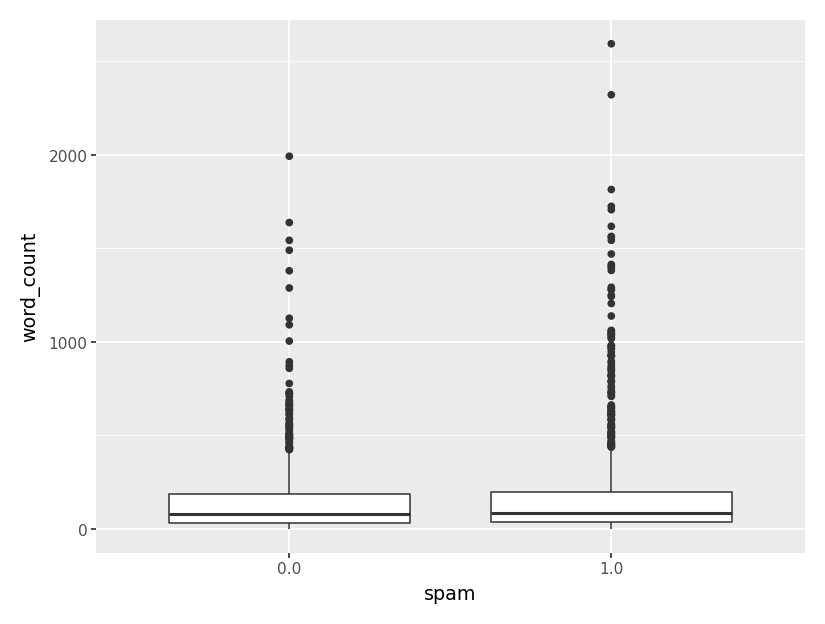

In [18]:
from plotnine import *

(
    ggplot(known, aes(x="spam", y="word_count"))
    + geom_boxplot()
)

In [21]:
tf_known = tf_df.loc[known.index]
mean_tf_by_spam = tf_known.groupby(known["spam"]).mean().T
for status in [0, 1]:
    display(mean_tf_by_spam[status].sort_values(ascending=False).head(10))

<positron-console-cell-21>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


the      4.795980
to       3.958794
ect      3.634171
and      1.950754
hou      1.913568
for      1.875377
enron    1.609045
on       1.547739
of       1.468342
this     1.300503
Name: 0.0, dtype: float64

the     4.888325
to      3.524873
and     3.394924
of      3.084264
in      2.095431
you     1.854822
for     1.678173
this    1.559391
is      1.469036
your    1.233503
Name: 1.0, dtype: float64

7\. Now consider the 10 emails for which the true spam status is unknown. How might you decide if each email is spam or not? Brainstorm some ideas before proceeding. How can you use the TF and TF-IDF matrices for emails with known spam status?

**Compare each unknown email's TF-IDF vector with the vectors of known emails to determine which may or may not be spam. If a majority of the closest emails are spam I would classify it as spam, and vice versa.**

8\. Consider just one email with unknown spam status, with `loc` 1980. Compute the cosine distance between the TF representation of this email and the TF representation of each of the emails with known spam status.

In [40]:
from matplotlib.cbook import simple_linear_interpolation
from sklearn.metrics.pairwise import cosine_similarity

sim_tf = pd.DataFrame(cosine_similarity(tf_df), index=corpus.index, columns=corpus.index)

tf_results = known[["spam", "subject"]].copy()

tf_results["cosine_distance"] = 1 - (sim_tf.loc[1980, known.index])

9\. Sort the results of the previous part to examine the emails with known spam status that are most similar to the unknown email. If you had to determine if the unknown email was spam or not, which would you pick and why?

In [41]:
nearest_tf = tf_results.sort_values("cosine_distance")
display(nearest_tf.head(10))

# Use the majority label among the 5 closest known emails.
tf_prediction = nearest_tf.head(5)["spam"].value_counts().idxmax()
tf_prediction

,spam,subject,cosine_distance
1889,1.0,please update your account details with citibank,0.393060
1032,1.0,can you facilitate ?,0.398488
1376,1.0,from dr kenneth,0.408606
714,0.0,75 th anniversary celebration,0.414644
1110,1.0,my site links to your site now,0.415807
26,0.0,re : tglo status,0.418573
180,0.0,fw : waha hubco,0.423172
879,0.0,dallas june hoop - it - up is coming to town !,0.424620
713,0.0,fw : hpl imbalance payback,0.427930
139,0.0,re : tglo status,0.434841


np.float64(1.0)

**4 of the 5 closest emails are classified as spam. Based on this I would classify the email as spam**

10\. Repeat the two previous parts using TF-IDF instead of TF. Do the results change?

In [42]:
sim_tfidf = pd.DataFrame(cosine_similarity(tfidf_df), index=corpus.index, columns=corpus.index)

tfidf_results = known[["spam", "subject"]].copy()

tfidf_results["cosine_distance"] = 1 - (sim_tfidf.loc[1980, known.index])

nearest_tfidf = tfidf_results.sort_values("cosine_distance")
display(nearest_tfidf.head(10))

# Use the majority label among the 5 closest known emails.
tfidf_prediction = nearest_tf.head(5)["spam"].value_counts().idxmax()
tf_prediction

,spam,subject,cosine_distance
1032,1.0,can you facilitate ?,0.755245
1977,1.0,reply soon ! ! !,0.780917
48,0.0,tetco / hpl ( enerfin ) meter # 986892,0.787975
1689,1.0,how are you today ?,0.790205
1796,1.0,urgent assistance,0.795094
180,0.0,fw : waha hubco,0.797415
586,0.0,re : entex volumes,0.798537
1376,1.0,from dr kenneth,0.799377
279,0.0,enron files chapter 11 reorganization,0.799969
1021,1.0,urgent reply,0.801259


np.float64(1.0)

11\. Now proceed in a similar manner to "guess" the spam status of each of the unknown emails.

In [43]:
known_index = emails.index[emails["spam"].notna()]
unknown_index = emails.index[emails["spam"].isna()]
guesses = emails.loc[unknown_index, ["subject"]].copy()

for i in unknown_index:
    closest_tf = sim_tf.loc[i, known_index].sort_values(ascending=False).head(5)
    closest_tfidf = sim_tfidf.loc[i, known_index].sort_values(ascending=False).head(5)

    guesses.loc[i, "tf_prediction"] = emails.loc[closest_tf.index, "spam"].value_counts().idxmax()
    guesses.loc[i, "tfidf_prediction"] = emails.loc[closest_tfidf.index, "spam"].value_counts().idxmax()

display(guesses)

,subject,tf_prediction,tfidf_prediction
1980,let ' s talk about your home loan .,1.0,1.0
1981,intraday eastrans nomination change for 9 / 6 ...,0.0,0.0
1982,"frontrea plant , gas",0.0,0.0
1983,re : meter 5892,0.0,0.0
1984,eastrans nomination change effective 8 / 3 / 00,0.0,0.0
1985,customer reciept # 4359 bn winkle,1.0,1.0
1986,internet pharmacy - smart prices,1.0,1.0
1987,victory at last,1.0,1.0
1988,free pay per view,1.0,1.0
1989,87 % off for all new software . darned canniba...,0.0,0.0
